In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!unzip -q "/content/drive/MyDrive/data/dataset.zip" -d .
!ls            # expect a 'dataset' folder
!ls dataset    # expect 'set 23' and 'val 23'

dataset  drive	sample_data
'set 23'  'val 23'


In [ ]:
import random
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

# --- Mirror shared/config.py + shared/data.py: leakage-free STRATIFIED split ---
# This replaces image_dataset_from_directory (which does a non-stratified global
# split, no antialias, no duplicate exclusion) so the notebook matches the .py.
IMAGE_SIZE = 256
IMG_SIZE = (IMAGE_SIZE, IMAGE_SIZE)
BATCH_SIZE = 8
SEED = 42
TUNING_SPLIT = 0.15
NUM_CLASSES = 4
CLASS_NAMES = ["coastal_mansion", "dense_residential", "nursing_home", "sparse_residential"]

TRAIN_DIR = "/content/dataset/set 23"
VAL_DIR   = "/content/dataset/val 23"

# Byte-identical images assigned to conflicting classes -> dropped (matches shared/config.py).
EXCLUDED_TRAIN_FILES = (
    "coastal_mansion/coastalmansion029.jpg",
    "sparse_residential/sparseresidential021.jpg",
)


def _collect_labeled_paths(root, excluded=()):
    """Sorted image paths grouped by the fixed class order, minus exclusions."""
    root_path = Path(root)
    excluded = {Path(p).as_posix() for p in excluded}
    grouped = []
    for label, class_name in enumerate(CLASS_NAMES):
        class_dir = root_path / class_name
        class_paths = []
        for path in sorted(class_dir.iterdir()):
            if not path.is_file():
                continue
            if path.relative_to(root_path).as_posix() in excluded:
                continue
            class_paths.append((str(path), label))
        grouped.append(class_paths)
    return grouped


def _split_training_paths():
    """Deterministic per-class (stratified) 85/15 train/tuning split."""
    grouped = _collect_labeled_paths(TRAIN_DIR, EXCLUDED_TRAIN_FILES)
    training, tuning = [], []
    for label, class_paths in enumerate(grouped):
        shuffled = class_paths.copy()
        random.Random(SEED + label).shuffle(shuffled)
        tuning_count = max(1, round(len(shuffled) * TUNING_SPLIT))
        tuning.extend(shuffled[:tuning_count])
        training.extend(shuffled[tuning_count:])
    random.Random(SEED).shuffle(training)
    random.Random(SEED).shuffle(tuning)
    return training, tuning


def _decode_image(path, label):
    """Read JPEG -> antialias resize -> raw [0,255] float -> one-hot label."""
    image = tf.io.decode_jpeg(tf.io.read_file(path), channels=3)
    image = tf.image.resize(image, IMG_SIZE, method="bilinear", antialias=True)
    image = tf.clip_by_value(tf.cast(image, tf.float32), 0.0, 255.0)
    return image, tf.one_hot(label, depth=NUM_CLASSES)


def _build_dataset(labeled_paths, shuffle, batch_size=BATCH_SIZE):
    paths = [p for p, _ in labeled_paths]
    labels = [l for _, l in labeled_paths]
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(_decode_image, num_parallel_calls=tf.data.AUTOTUNE, deterministic=True)
    ds = ds.cache()
    if shuffle:
        ds = ds.shuffle(len(labeled_paths), seed=SEED, reshuffle_each_iteration=True)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


# train_ds = model training data; val_ds = internal TUNING split (both from set 23).
training_paths, tuning_paths = _split_training_paths()
train_ds = _build_dataset(training_paths, shuffle=True)
val_ds   = _build_dataset(tuning_paths, shuffle=False)

num_classes = NUM_CLASSES
class_names = CLASS_NAMES
print(f"train: {len(training_paths)}  tuning: {len(tuning_paths)}  classes: {num_classes}")

In [ ]:
# Labels are ALREADY one-hot from _decode_image in the loader cell above, so we
# must NOT map one_hot again (that would try to one-hot an already-encoded vector).
# Kept defined only for reference.
def one_hot_encode_labels(image, label):
    return image, tf.one_hot(label, depth=num_classes)

print("Labels are already one-hot from the loader; no extra mapping applied.")

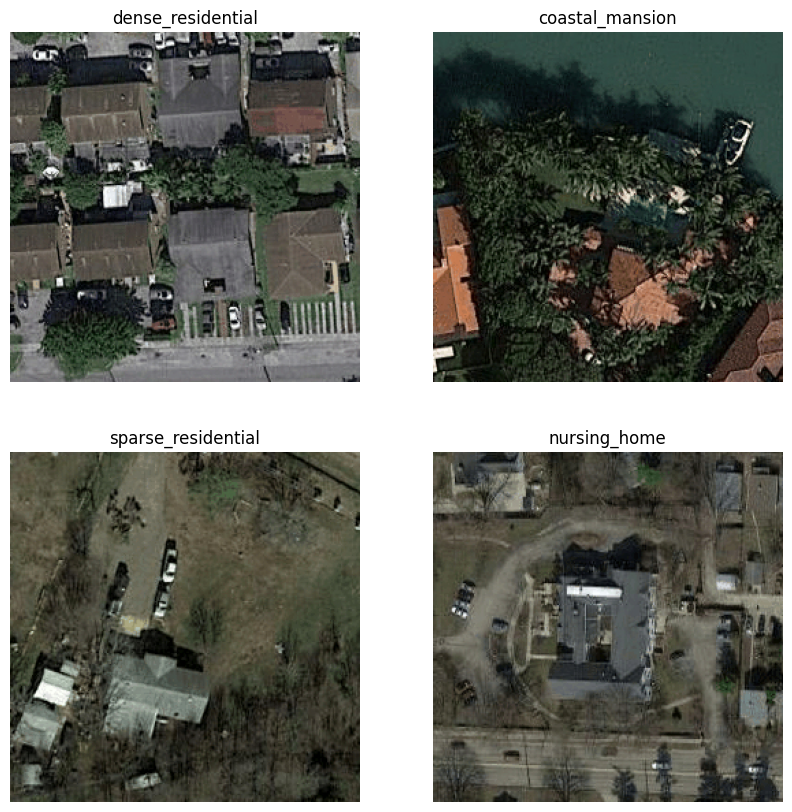

In [77]:
import numpy as np

# Get class names from train_ds
# class_names = train_ds.class_names # This line caused the error

# Dictionary to store one image per class
images_per_class = {}

# Iterate through the training dataset to collect one image for each class
for images, labels in train_ds:
    for i in range(images.shape[0]):
        # For one-hot encoded labels, we need to find the index of the '1'
        label_index = np.argmax(labels[i].numpy())
        class_name = class_names[label_index]
        if class_name not in images_per_class:
            images_per_class[class_name] = images[i].numpy()

    if len(images_per_class) == len(class_names): # Stop once all classes have an image
        break

# Display one image for each class
plt.figure(figsize=(10, 10))
for i, (class_name, image) in enumerate(images_per_class.items()):
    ax = plt.subplot(2, 2, i + 1) # Arrange in 2x2 grid
    plt.imshow(image.astype("uint8"))
    plt.title(class_name)
    plt.axis("off")
plt.show()

(32, 256, 256, 3)
(32, 4)


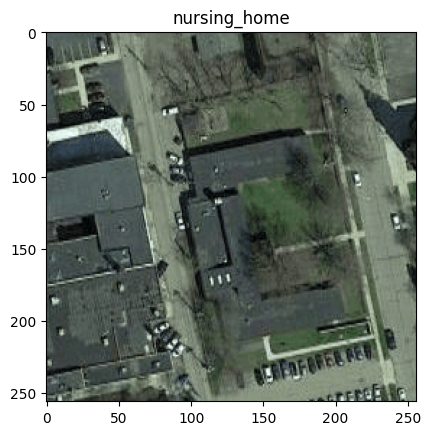

In [82]:
image, label = next(iter(train_ds))
print(image.shape)
print(label.shape)

# class_names = train_ds.class_names # Removed this line as class_names is already defined globally
get_label_name = lambda x: class_names[tf.argmax(x).numpy()]

plt.imshow(image[0].numpy().astype("uint8"))
plt.title(get_label_name(label[0]))
plt.show()

In [83]:
def augmentation() -> keras.Sequential:
    return keras.Sequential(
        [
            # All four flip orientations are valid for top-down aerial views.
            keras.layers.RandomFlip(
                "horizontal_and_vertical", seed=42
            ),
            # Rotation up to +/- 180 deg (aerial has no canonical "up"). Arbitrary
            # rotation is fine for classification -- the Roboflow "90-deg only"
            # guidance targets bounding-box preservation in detection, which does
            # not apply here. fill_mode="reflect" avoids black corner artifacts.
            keras.layers.RandomRotation(
                factor=0.5, fill_mode="reflect", seed=42
            ),
            # Scale jitter -- robustness to capture altitude / zoom differences.
            keras.layers.RandomZoom(0.2, seed=42),
            # Mild photometric jitter -- lighting/sensor robustness without
            # washing out fine-grained texture cues (kept low; 0.5 blew images
            # to near-black/white).
            keras.layers.RandomContrast(factor=0.1, seed=42),
            keras.layers.RandomBrightness(
                factor=0.1, value_range=(0, 255), seed=42
            ),
        ],
 name="aerial_augmentation")

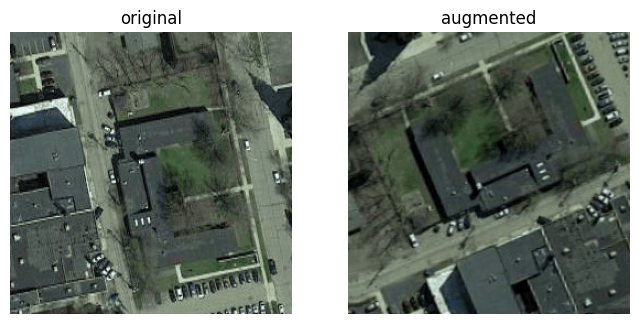

In [84]:
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(image[0].numpy().astype("uint8"))     # original: [0,255] → uint8
plt.title("original"); plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(augmentation()(image)[0].numpy().astype("uint8"))   # tell imshow it's [0,255]
plt.title("augmented"); plt.axis("off")
plt.show()


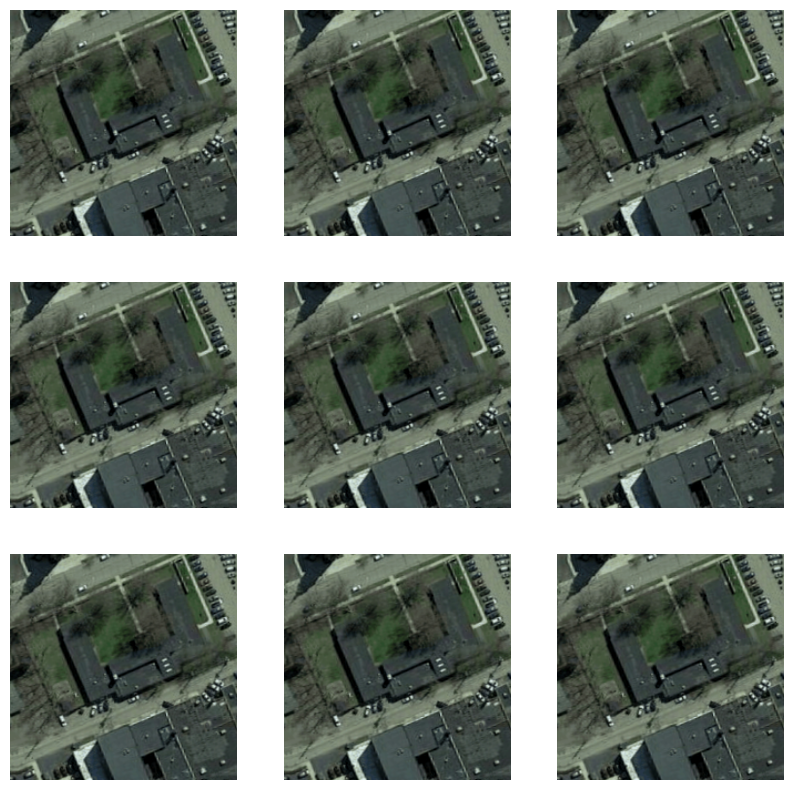

In [85]:
plt.figure(figsize=(10, 10))
for i in range(9):
  augmented_image = augmentation()(image)
  ax = plt.subplot(3, 3, i + 1)
  plt.imshow(augmentation()(image)[0].numpy().astype("uint8"))   # tell imshow it's [0,255]
  plt.axis("off")

In [86]:
print("Min and max pixel values:", result.numpy().min(), result.numpy().max())

Min and max pixel values: 0.0 1.0


In [ ]:
def build_model(num_classes: int, augmentation: keras.Sequential) -> keras.Model:
    inputs = keras.Input(shape=IMG_SIZE + (3,))

    x = augmentation(inputs)
    # Augmentation works on raw [0,255]; rescale to [0,1] AFTER it, before the
    # convs -- matches shared custom_cnn.py.
    x = keras.layers.Rescaling(1./255)(x)

    # Convolutional Block 1
    x = keras.layers.Conv2D(256,(3,3), activation='relu', strides=(1,1),kernel_regularizer=keras.regularizers.l2(0.0001))(x)
    x = keras.layers.MaxPooling2D((2, 2), padding='valid')(x)
    x = keras.layers.BatchNormalization()(x)

    # Convolutional Block 2
    x = keras.layers.Conv2D(128,(3,3), activation='relu', strides=(1,1),kernel_regularizer=keras.regularizers.l2(0.0001))(x)
    x = keras.layers.MaxPooling2D((2, 2), padding='valid')(x)
    x = keras.layers.BatchNormalization()(x)

    # Convolutional Block 3
    x = keras.layers.Conv2D(128,(3,3), activation='relu', strides=(1,1),kernel_regularizer=keras.regularizers.l2(0.0001))(x)

    # Convolutional Block 4
    x = keras.layers.Conv2D(128,(3,3), activation='relu', strides=(1,1),kernel_regularizer=keras.regularizers.l2(0.0001))(x)

    # Convolutional Block 5
    x = keras.layers.Conv2D(64,(3,3), activation='relu', strides=(1,1),kernel_regularizer=keras.regularizers.l2(0.0001))(x)
    x = keras.layers.MaxPooling2D((2, 2), padding='valid')(x)

    # Fully Connected Layers
    x = keras.layers.Flatten()(x)
    x = keras.layers.Dense(512, activation='relu')(x)
    x = keras.layers.Dense(256, activation='relu')(x)
    x = keras.layers.Dense(64, activation='relu')(x)
    x = keras.layers.Dense(16, activation='relu')(x)
    outputs = keras.layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs=inputs, outputs=outputs)
    return model

In [88]:
model = build_model(num_classes, augmentation())
model.summary()

Model: "functional_166"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_165 (InputLayer)    │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aerial_augmentation             │ (None, 256, 256, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 254, 254, 256)  │         7,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 127, 127, 256)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 127, 127, 256)  │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 125, 125, 128)  │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 62, 62, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 62, 62, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 60, 60, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 58, 58, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 56, 56, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │    25,690,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,512,212 (101.14 MB)

 Trainable params: 26,511,444 (101.13 MB)

 Non-trainable params: 768 (3.00 KB)

In [ ]:
EPOCH = 32
LEARNING_RATE = 0.00025
CHECKPOINT_PATH = "custom_cnn_best.keras"

# Metric is CategoricalAccuracy -> its validation key is "val_categorical_accuracy".
callback = [
    # Keep the BEST epoch (matches train.py's ModelCheckpoint).
    keras.callbacks.ModelCheckpoint(
        CHECKPOINT_PATH,
        monitor="val_categorical_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    # Stop when tuning accuracy stops improving; restore the best weights
    # (matches train.py's EarlyStopping). patience=8 leaves room for the LR drop.
    keras.callbacks.EarlyStopping(
        monitor="val_categorical_accuracy",
        mode="max",
        patience=8,
        restore_best_weights=True,
        verbose=1,
    ),
    # Custom_cnn's own researched LR scheduler (kept).
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.25,
        patience=4,
        min_lr=1e-6,
        verbose=1,
    ),
]

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=[keras.metrics.CategoricalAccuracy()],
)

In [ ]:
run_model = model.fit(
    train_ds,
    epochs=EPOCH,
    validation_data=val_ds,
    callbacks=callback
)

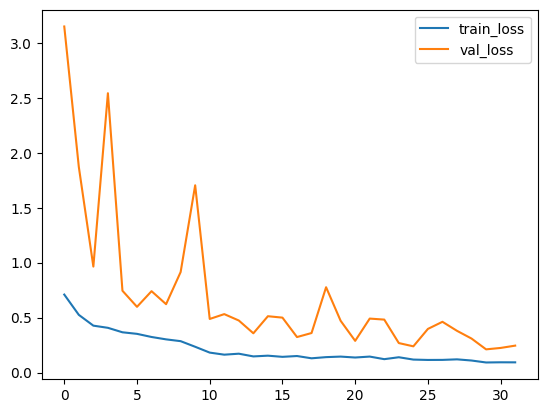

In [94]:
plt.plot(run_model.history['loss'], label='train_loss')
plt.plot(run_model.history['val_loss'], label='val_loss')
plt.legend()
plt.show()

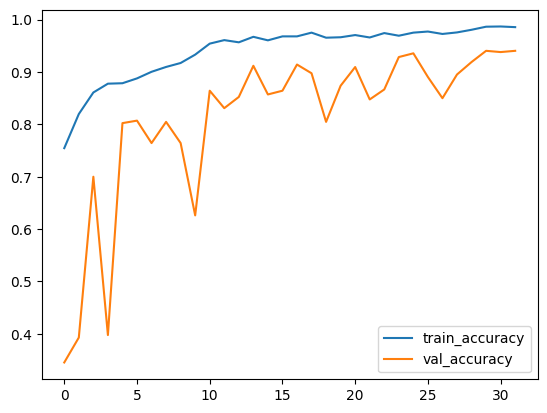

In [96]:
plt.plot(run_model.history['categorical_accuracy'], label='train_accuracy')
plt.plot(run_model.history['val_categorical_accuracy'], label='val_accuracy')
plt.legend()
plt.show()

In [ ]:
# Held-out TEST set (val 23), built the SAME way as shared/data.py:
# antialias resize + one-hot, NO exclusions, NO shuffle.
held_out_grouped = _collect_labeled_paths(VAL_DIR)
held_out_paths = [item for group in held_out_grouped for item in group]
real_test = _build_dataset(held_out_paths, shuffle=False)

# Evaluate the BEST checkpoint (restored by EarlyStopping / saved by ModelCheckpoint),
# matching train.py which reports the best-epoch model.
best_model = keras.models.load_model(CHECKPOINT_PATH)
test_loss, test_acc = best_model.evaluate(real_test)
print(f"Test accuracy: {test_acc * 100:.2f}%")

In [ ]:
model.save('drive/MyDrive/test_customcnn.keras')

### Methods to Increase Model Accuracy:

1.  **Data Augmentation:** While you already have some data augmentation, you can explore more aggressive transformations (e.g., higher rotation angles, more zoom, color jittering, etc.) to further increase the diversity of your training data. This helps the model generalize better to unseen images.

2.  **Transfer Learning:** This is often the most effective way to achieve high accuracy, especially when you have a relatively small dataset. Instead of training a model from scratch, you can use a pre-trained convolutional neural network (like ResNet, VGG, Inception, EfficientNet, etc.) that has learned powerful features from a massive dataset (e.g., ImageNet). You can then fine-tune this pre-trained model on your specific dataset.

3.  **Hyperparameter Tuning:** Experiment with different hyperparameters such as:
    *   **Learning Rate:** The current learning rate might not be optimal. You could try a learning rate scheduler or run experiments with different fixed learning rates.
    *   **Batch Size:** Different batch sizes can affect training stability and generalization.
    *   **Number of Epochs:** You might need more epochs if the model is still learning, or fewer if it's overfitting early.
    *   **Optimizer:** While Adam is a good general-purpose optimizer, trying others like SGD with momentum or RMSprop might yield better results.

4.  **Regularization Techniques:** To combat overfitting, which can limit accuracy on unseen data:
    *   **Dropout:** You already have some dropout layers. You could experiment with different dropout rates or add more dropout layers.
    *   **L1/L2 Regularization:** Add L1 or L2 regularization to your model's layers to penalize large weights.

5.  **Model Architecture Improvements:** Although your current custom CNN is a good start, you could explore:
    *   **Deeper Networks:** More convolutional layers can sometimes capture more complex features.
    *   **Different Kernel Sizes:** Experiment with `(5,5)` or `(7,7)` kernels in earlier layers for broader feature detection.
    *   **Residual Connections (ResNet-like blocks):** These help with training deeper networks by addressing the vanishing gradient problem.

6.  **Ensemble Methods:** Train multiple different models (e.g., different architectures or trained with different random seeds) and combine their predictions. This often leads to more robust and accurate results.